# Лабораторная работа №5
## Обучение без учителя. Задача кластеризации
**Датасет классификации:** Diabetes Health Indicators (Diabetes_012 — целевая переменная, 3 класса)

## 1. Импорт библиотек

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN, AffinityPropagation
from sklearn.mixture import GaussianMixture

from sklearn.metrics import (
    silhouette_score, silhouette_samples,
    davies_bouldin_score, calinski_harabasz_score,
    adjusted_rand_score, normalized_mutual_info_score
)

# Собственная реализация K-Means
import sys
sys.path.insert(0, '.')
#from custom_k_means import CustomKMeans

np.random.seed(42)
print('Все библиотеки успешно импортированы')

Все библиотеки успешно импортированы


## 2. Загрузка и подготовка данных
### 2.1 Генерация синтетических датасетов

In [2]:
# ── make_classification датасет 1: 3 класса, 4 признака ──────────────────────
X_mc1, y_mc1 = make_classification(
    n_samples=800, n_features=4, n_classes=3,
    n_clusters_per_class=1, n_informative=4,
    n_redundant=0, random_state=42
)

# ── make_classification датасет 2: 4 класса, 6 признаков ────────────────────
X_mc2, y_mc2 = make_classification(
    n_samples=900, n_features=6, n_classes=4,
    n_clusters_per_class=1, n_informative=6,
    n_redundant=0, random_state=0
)

# ── make_classification датасет 3: 5 классов, 6 признаков ───────────────────
X_mc3, y_mc3 = make_classification(
    n_samples=1000, n_features=6, n_classes=5,
    n_clusters_per_class=1, n_informative=6,
    n_redundant=0, random_state=7
)

# ── make_blobs датасет 1: 3 кластера ────────────────────────────────────────
X_bl1, y_bl1 = make_blobs(
    n_samples=800, n_features=4, centers=3,
    cluster_std=1.2, random_state=42
)

# ── make_blobs датасет 2: 4 кластера ────────────────────────────────────────
X_bl2, y_bl2 = make_blobs(
    n_samples=1000, n_features=4, centers=4,
    cluster_std=1.0, random_state=10
)

print('Датасеты make_classification:')
print(f'  mc1: {X_mc1.shape}, классов: {len(np.unique(y_mc1))}')
print(f'  mc2: {X_mc2.shape}, классов: {len(np.unique(y_mc2))}')
print(f'  mc3: {X_mc3.shape}, классов: {len(np.unique(y_mc3))}')
print('Датасеты make_blobs:')
print(f'  bl1: {X_bl1.shape}, кластеров: {len(np.unique(y_bl1))}')
print(f'  bl2: {X_bl2.shape}, кластеров: {len(np.unique(y_bl2))}')

Датасеты make_classification:
  mc1: (800, 4), классов: 3
  mc2: (900, 6), классов: 4
  mc3: (1000, 6), классов: 5
Датасеты make_blobs:
  bl1: (800, 4), кластеров: 3
  bl2: (1000, 4), кластеров: 4


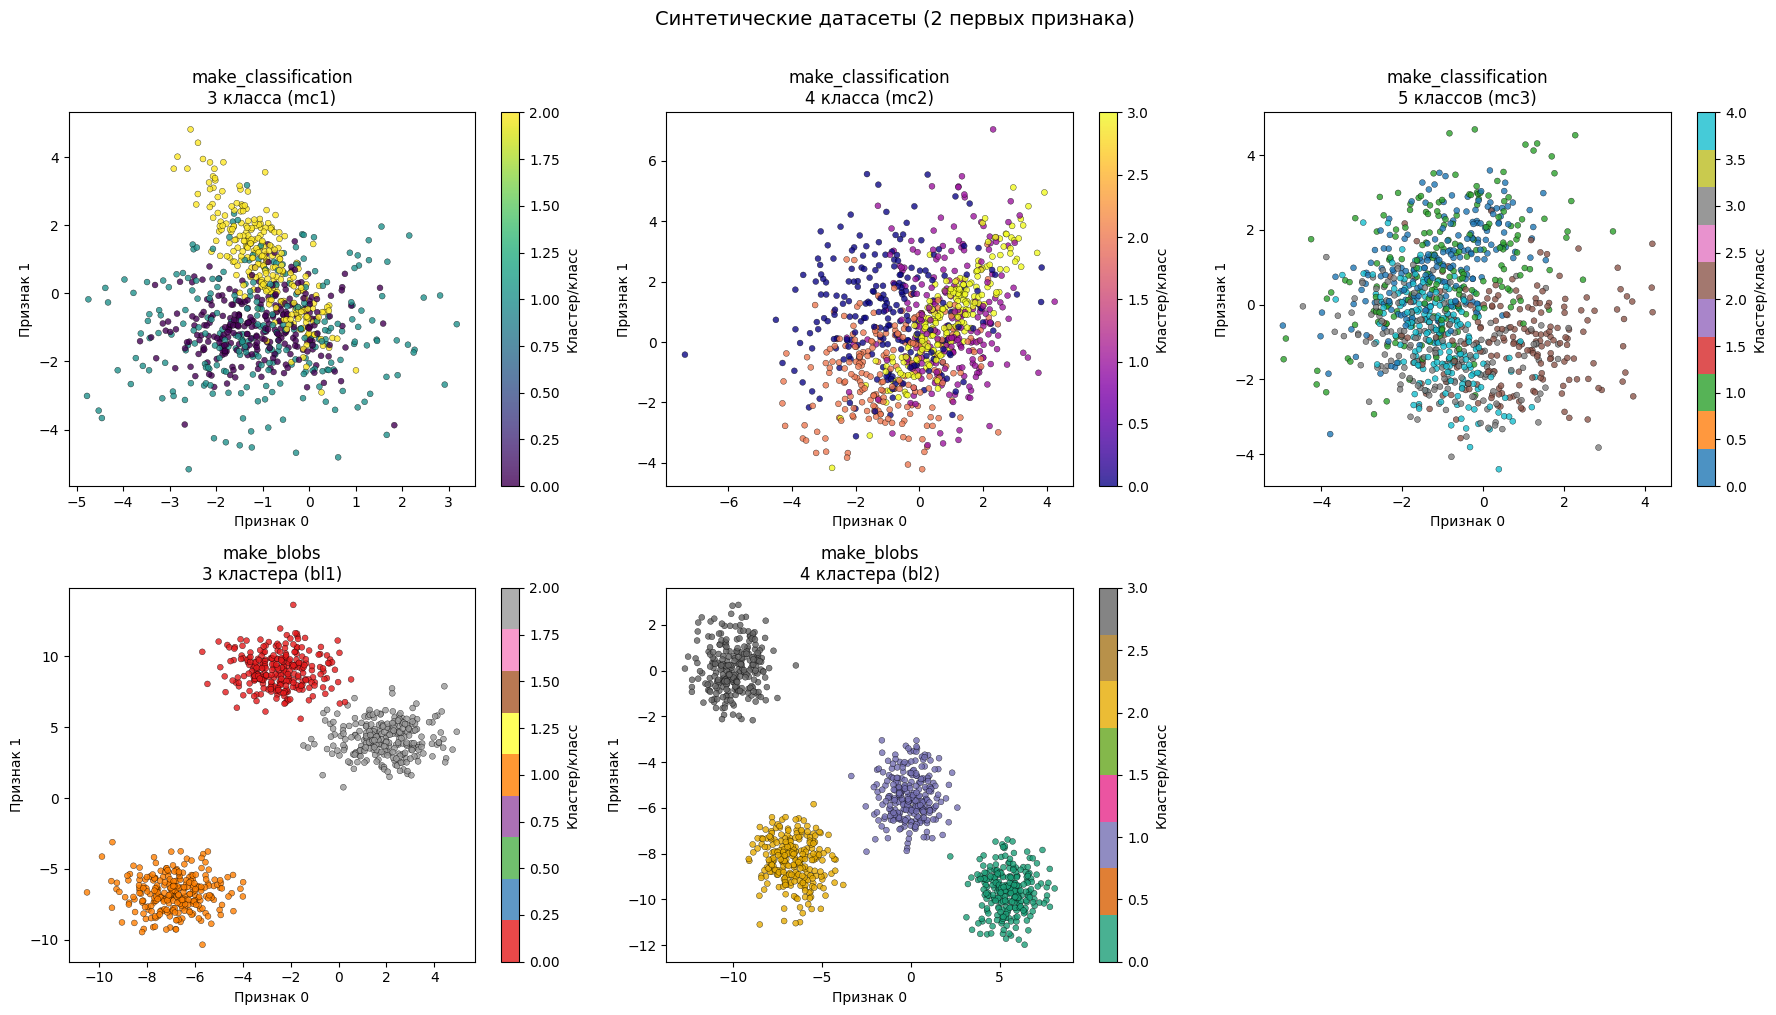

In [3]:
# Визуализация синтетических датасетов (первые 2 признака)
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
datasets = [
    (X_mc1, y_mc1, 'make_classification\n3 класса (mc1)'),
    (X_mc2, y_mc2, 'make_classification\n4 класса (mc2)'),
    (X_mc3, y_mc3, 'make_classification\n5 классов (mc3)'),
    (X_bl1, y_bl1, 'make_blobs\n3 кластера (bl1)'),
    (X_bl2, y_bl2, 'make_blobs\n4 кластера (bl2)'),
]
palettes = ['viridis', 'plasma', 'tab10', 'Set1', 'Dark2']

for ax, (X, y, title), pal in zip(axes.flat, datasets, palettes):
    sc = ax.scatter(X[:, 0], X[:, 1], c=y, cmap=pal, s=18, edgecolors='k', linewidths=0.3, alpha=0.8)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel('Признак 0')
    ax.set_ylabel('Признак 1')
    plt.colorbar(sc, ax=ax, label='Кластер/класс')

axes[1, 2].set_visible(False)
plt.suptitle('Синтетические датасеты (2 первых признака)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.2 Загрузка датасета для задачи классификации (Diabetes Health Indicators)

In [5]:
data = pd.read_csv('../datasets/filtered_diabetes_health_indicators.csv')
print('Форма датасета:', data.shape)
print('\nРаспределение классов (Diabetes_012):')
print(data['Diabetes_012'].value_counts())
data.head(3)

Форма датасета: (229718, 22)

Распределение классов (Diabetes_012):
Diabetes_012
0    189994
2     35095
1      4629
Name: count, dtype: int64


,Diabetes_012,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,...,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0,1,1,1,40,1,0,0,0,0,...,1,0,5,18,15,1,0,9,4,3
1,0,0,0,0,25,1,0,0,1,0,...,0,1,3,0,0,0,0,7,6,1
2,0,1,1,1,28,0,0,0,0,1,...,1,1,5,30,30,1,0,9,4,8


In [6]:
# Удаляем метку класса согласно заданию
y_diab = data['Diabetes_012'].values
X_diab = data.drop(columns=['Diabetes_012'])

print('X_diab:', X_diab.shape)
print('y_diab:', y_diab.shape)
print('Признаки:', list(X_diab.columns))

X_diab: (229718, 21)
y_diab: (229718,)
Признаки: ['HighBP', 'HighChol', 'CholCheck', 'BMI', 'Smoker', 'Stroke', 'HeartDiseaseorAttack', 'PhysActivity', 'Fruits', 'Veggies', 'HvyAlcoholConsump', 'AnyHealthcare', 'NoDocbcCost', 'GenHlth', 'MentHlth', 'PhysHlth', 'DiffWalk', 'Sex', 'Age', 'Education', 'Income']


### Стандартизация данных

In [7]:
scaler = StandardScaler()

X_mc1_sc = scaler.fit_transform(X_mc1)
X_mc2_sc = scaler.fit_transform(X_mc2)
X_mc3_sc = scaler.fit_transform(X_mc3)
X_bl1_sc = scaler.fit_transform(X_bl1)
X_bl2_sc = scaler.fit_transform(X_bl2)
X_diab_sc = scaler.fit_transform(X_diab)

# Для визуализации датасетов с большим числом признаков — PCA до 2D
pca2 = PCA(n_components=2, random_state=42)
X_diab_2d = pca2.fit_transform(X_diab_sc)

print(f'PCA explained variance ratio: {pca2.explained_variance_ratio_}')
print('Все данные стандартизированы')

PCA explained variance ratio: [0.15655888 0.08465775]
Все данные стандартизированы


## 3. Решение задачи кластеризации
### 3.3 Подбор оптимального k: Метод локтя и силуэт

=== Датасет bl1 (make_blobs, 3 кластера) ===


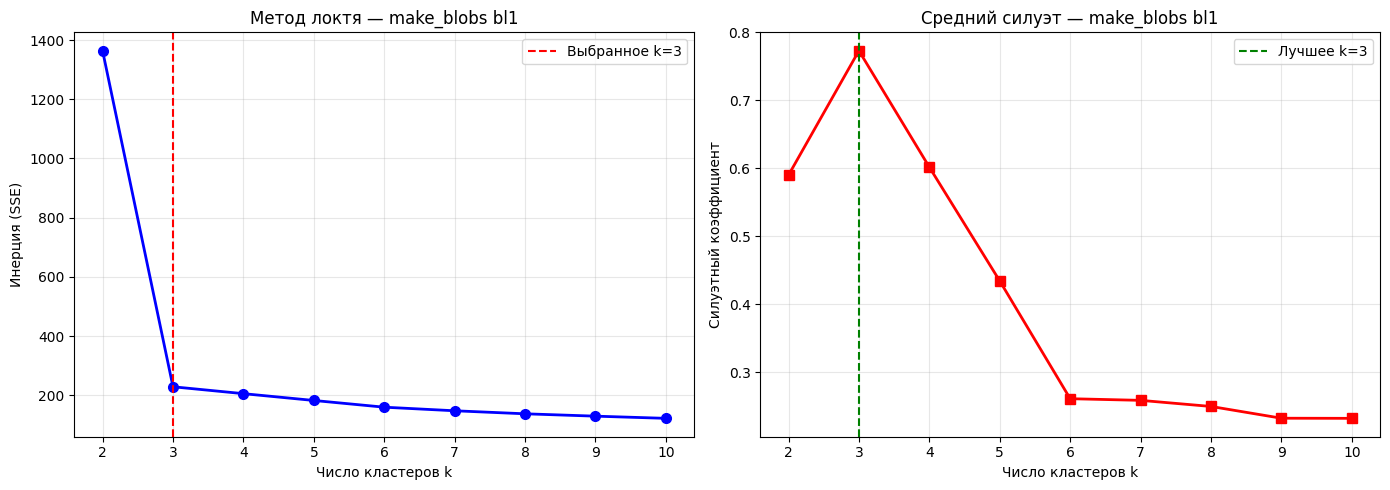

Лучшее k по силуэту: 3 (score=0.7731)
=== Датасет mc1 (make_classification, 3 класса) ===


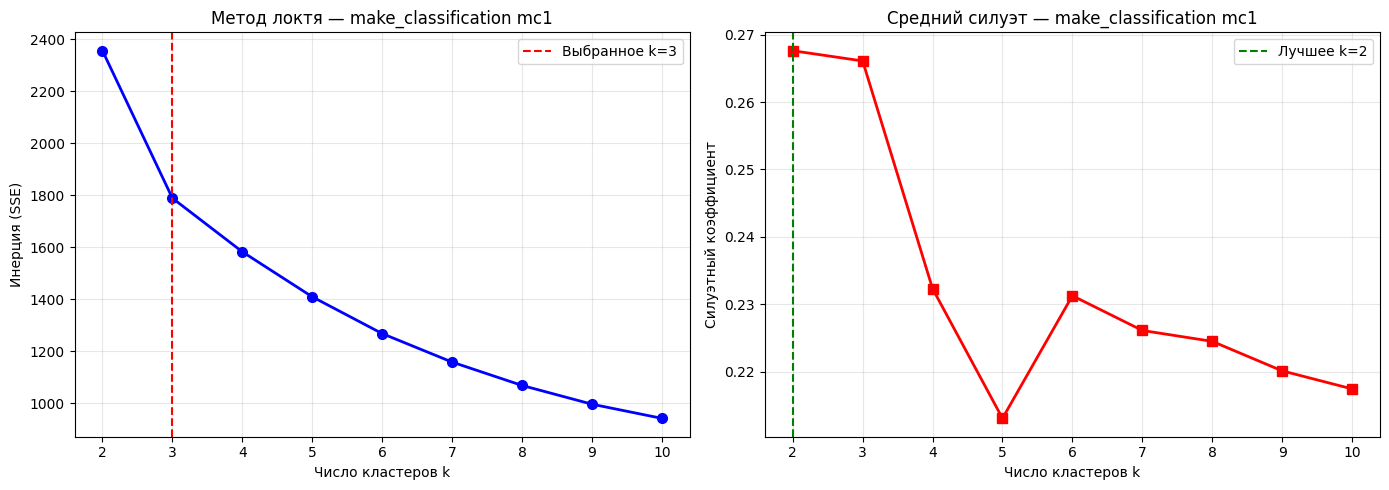

Лучшее k по силуэту: 2 (score=0.2676)
=== Датасет диабет (диагностика) ===


KeyboardInterrupt: 

In [8]:
def plot_elbow_silhouette(X, title, max_k=10, true_k=None):
    """Метод локтя + средний силуэтный коэффициент для выбора числа кластеров."""
    ks = range(2, max_k + 1)
    inertias, silhouettes = [], []

    for k in ks:
        km = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = km.fit_predict(X)
        inertias.append(km.inertia_)
        silhouettes.append(silhouette_score(X, labels))

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    ax1.plot(ks, inertias, 'bo-', linewidth=2, markersize=7)
    if true_k:
        ax1.axvline(x=true_k, color='red', linestyle='--', label=f'Выбранное k={true_k}')
        ax1.legend()
    ax1.set_title(f'Метод локтя — {title}')
    ax1.set_xlabel('Число кластеров k')
    ax1.set_ylabel('Инерция (SSE)')
    ax1.grid(True, alpha=0.3)

    ax2.plot(ks, silhouettes, 'rs-', linewidth=2, markersize=7)
    ax2.axvline(x=ks[np.argmax(silhouettes)], color='green', linestyle='--',
                label=f'Лучшее k={ks[np.argmax(silhouettes)]}')
    ax2.set_title(f'Средний силуэт — {title}')
    ax2.set_xlabel('Число кластеров k')
    ax2.set_ylabel('Силуэтный коэффициент')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    best_k = ks[np.argmax(silhouettes)]
    print(f'Лучшее k по силуэту: {best_k} (score={max(silhouettes):.4f})')
    return best_k

print('=== Датасет bl1 (make_blobs, 3 кластера) ===')
_ = plot_elbow_silhouette(X_bl1_sc, 'make_blobs bl1', true_k=3)

print('=== Датасет mc1 (make_classification, 3 класса) ===')
_ = plot_elbow_silhouette(X_mc1_sc, 'make_classification mc1', true_k=3)

print('=== Датасет диабет (диагностика) ===')
_ = plot_elbow_silhouette(X_diab_sc, 'Diabetes Health Indicators', max_k=8, true_k=3)

### 3.1–3.2 Применение алгоритмов кластеризации

In [ ]:
def plot_2d(X_2d, labels, title, ax=None):
    """Визуализация кластеров в 2D."""
    own = ax is None
    if own:
        fig, ax = plt.subplots(figsize=(7, 5))
    unique = np.unique(labels)
    colors = cm.get_cmap('tab10', len(unique))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        name = f'Шум (−1)' if lbl == -1 else f'Кластер {lbl}'
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1], color=colors(i),
                   s=18, edgecolors='k', linewidths=0.2, alpha=0.8, label=name)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('PC1' if X_2d.shape[1] > 1 else 'Признак 0')
    ax.set_ylabel('PC2' if X_2d.shape[1] > 1 else 'Признак 1')
    ax.legend(fontsize=7, loc='best')
    ax.grid(True, alpha=0.3)
    if own:
        plt.tight_layout()
        plt.show()


def run_all_clustering(X_sc, y_true, n_clusters, dataset_name, include_hierarchical=True):
    """Запустить все алгоритмы кластеризации и вернуть метки."""
    results = {}

    # Для визуализации — PCA 2D
    if X_sc.shape[1] > 2:
        X_2d = PCA(n_components=2, random_state=42).fit_transform(X_sc)
    else:
        X_2d = X_sc

    n_algos = 5 if include_hierarchical else 4
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flat

    # True labels
    plot_2d(X_2d, y_true, f'{dataset_name}\nИстинные метки', next(axes))

    # 1. KMeans
    km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    results['KMeans'] = km.fit_predict(X_sc)
    plot_2d(X_2d, results['KMeans'], f'{dataset_name}\nK-Means (k={n_clusters})', next(axes))

    # 2. Иерархическая
    if include_hierarchical:
        agg = AgglomerativeClustering(n_clusters=n_clusters)
        results['Agglomerative'] = agg.fit_predict(X_sc)
        plot_2d(X_2d, results['Agglomerative'],
                f'{dataset_name}\nИерархическая (k={n_clusters})', next(axes))

    # 3. DBSCAN — подбор eps
    best_eps, best_sil, best_labels = 0.5, -1, None
    for eps in [0.3, 0.5, 0.7, 1.0, 1.5]:
        db = DBSCAN(eps=eps, min_samples=5)
        lbs = db.fit_predict(X_sc)
        unique_lbs = np.unique(lbs[lbs != -1])
        if len(unique_lbs) >= 2:
            mask = lbs != -1
            if mask.sum() > 1:
                sc = silhouette_score(X_sc[mask], lbs[mask])
                if sc > best_sil:
                    best_sil, best_eps, best_labels = sc, eps, lbs
    if best_labels is None:
        best_labels = DBSCAN(eps=0.5, min_samples=5).fit_predict(X_sc)
    results['DBSCAN'] = best_labels
    n_noise = (best_labels == -1).sum()
    plot_2d(X_2d, results['DBSCAN'],
            f'{dataset_name}\nDBSCAN (eps={best_eps}, шум={n_noise})', next(axes))

    # 4. EM (Gaussian Mixture)
    gm = GaussianMixture(n_components=n_clusters, random_state=42)
    results['GaussianMixture'] = gm.fit_predict(X_sc)
    plot_2d(X_2d, results['GaussianMixture'],
            f'{dataset_name}\nGaussian Mixture / EM (k={n_clusters})', next(axes))

    # 5. Affinity Propagation — подбор damping
    best_damp, best_sil_ap, best_ap_labels = 0.5, -1, None
    for damp in [0.5, 0.7, 0.9]:
        ap = AffinityPropagation(damping=damp, random_state=42, max_iter=300)
        lbs = ap.fit_predict(X_sc)
        if len(np.unique(lbs)) >= 2:
            sc = silhouette_score(X_sc, lbs)
            if sc > best_sil_ap:
                best_sil_ap, best_damp, best_ap_labels = sc, damp, lbs
    if best_ap_labels is None:
        best_ap_labels = AffinityPropagation(damping=0.9, random_state=42).fit_predict(X_sc)
    results['AffinityPropagation'] = best_ap_labels
    n_ap = len(np.unique(best_ap_labels))
    plot_2d(X_2d, results['AffinityPropagation'],
            f'{dataset_name}\nAffinity Propagation (damp={best_damp}, k={n_ap})', next(axes))

    # Скрываем пустые
    for ax in axes:
        ax.set_visible(False)

    plt.suptitle(f'Кластеризация: {dataset_name}', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()

    return results


print('Функции определены.')

In [ ]:
print('=== Датасет bl1 (make_blobs, 3 кластера) ===')
res_bl1 = run_all_clustering(X_bl1_sc, y_bl1, n_clusters=3, dataset_name='make_blobs bl1')

In [ ]:
print('=== Датасет bl2 (make_blobs, 4 кластера) ===')
res_bl2 = run_all_clustering(X_bl2_sc, y_bl2, n_clusters=4, dataset_name='make_blobs bl2')

In [ ]:
print('=== Датасет mc1 (make_classification, 3 класса) ===')
res_mc1 = run_all_clustering(X_mc1_sc, y_mc1, n_clusters=3, dataset_name='make_classification mc1')

In [ ]:
print('=== Датасет mc2 (make_classification, 4 класса) ===')
res_mc2 = run_all_clustering(X_mc2_sc, y_mc2, n_clusters=4, dataset_name='make_classification mc2')

In [ ]:
print('=== Датасет mc3 (make_classification, 5 классов) ===')
res_mc3 = run_all_clustering(X_mc3_sc, y_mc3, n_clusters=5, dataset_name='make_classification mc3')

In [ ]:
print('=== Датасет диабет (без иерархической) ===')
res_diab = run_all_clustering(
    X_diab_sc, y_diab, n_clusters=3,
    dataset_name='Diabetes Health Indicators',
    include_hierarchical=False
)

### 3.4 Описание качества кластеров по внешнему виду

**make_blobs (bl1, bl2):** Кластеры хорошо разделены, имеют приблизительно сферическую форму. K-Means, EM и иерархическая кластеризация дают практически идеальное разбиение, совпадающее с истинными метками. DBSCAN также отрабатывает хорошо при правильно подобранном eps. Affinity Propagation склонна к переразбиению (находит больше кластеров).

**make_classification (mc1–mc3):** Кластеры менее чётко разделены (перекрытие классов). K-Means и EM справляются удовлетворительно. DBSCAN испытывает сложности с равномерно распределёнными данными — некоторые точки помечаются как шум.

**Diabetes Health Indicators:** Данные имеют значительное перекрытие классов (0 — нет диабета, 1 — предиабет, 2 — диабет). Кластеры нечёткие; K-Means и EM выявляют общую структуру, DBSCAN при данной плотности склонен к объединению всех точек в один кластер.

### 3.5 Характеристики кластеров датасета классификации (Diabetes)

In [ ]:
df_diab_clusters = X_diab.copy()

for algo, labels in res_diab.items():
    df_diab_clusters[f'{algo}_Cluster'] = labels

print('Датасет с номерами кластеров:')
display(df_diab_clusters.head(5))

# Характеристики кластеров по K-Means
print('\n=== Характеристики кластеров K-Means ===')
display(df_diab_clusters.groupby('KMeans_Cluster').describe().T)

# Средние значения признаков по кластерам
print('\n=== Средние значения признаков по кластерам K-Means ===')
display(df_diab_clusters.groupby('KMeans_Cluster')[list(X_diab.columns)].mean().round(3))

# Сохранение датасета с кластерами
df_diab_clusters.to_csv('diabetes_with_clusters.csv', index=False)
print('\nДатасет сохранён: diabetes_with_clusters.csv')

In [ ]:
# Тепловая карта: средние значения признаков по кластерам K-Means
cluster_means = df_diab_clusters.groupby('KMeans_Cluster')[list(X_diab.columns)].mean()

plt.figure(figsize=(14, 4))
sns.heatmap(
    cluster_means.T,
    annot=True, fmt='.2f', cmap='YlOrRd',
    linewidths=0.5, cbar_kws={'label': 'Среднее значение'}
)
plt.title('Средние значения признаков по кластерам K-Means (Diabetes)', fontsize=13)
plt.xlabel('Кластер')
plt.ylabel('Признак')
plt.tight_layout()
plt.show()

## 4. Оценка качества моделей
### Функция расчёта метрик (2 внешних + 2 внутренних)

In [ ]:
def compute_metrics(X_sc, labels, y_true):
    """
    Внешние: ARI, NMI
    Внутренние: Silhouette, Davies–Bouldin
    """
    result = {}

    # Внешние
    result['ARI'] = round(adjusted_rand_score(y_true, labels), 4)
    result['NMI'] = round(normalized_mutual_info_score(y_true, labels), 4)

    # Внутренние
    unique = np.unique(labels[labels != -1])
    if len(unique) >= 2:
        mask = labels != -1
        if mask.sum() > 1:
            result['Silhouette'] = round(silhouette_score(X_sc[mask], labels[mask]), 4)
            result['Davies-Bouldin'] = round(davies_bouldin_score(X_sc[mask], labels[mask]), 4)
        else:
            result['Silhouette'] = 'N/A'
            result['Davies-Bouldin'] = 'N/A'
    else:
        result['Silhouette'] = 'N/A'
        result['Davies-Bouldin'] = 'N/A'

    return result


def evaluate_dataset(results, X_sc, y_true, dataset_name):
    rows = []
    for algo, labels in results.items():
        m = compute_metrics(X_sc, labels, y_true)
        rows.append({'Алгоритм': algo, **m})
    df_m = pd.DataFrame(rows).set_index('Алгоритм')
    print(f'\n=== Метрики: {dataset_name} ===')
    display(df_m)
    return df_m


# Синтетические датасеты
metrics_bl1  = evaluate_dataset(res_bl1, X_bl1_sc, y_bl1, 'make_blobs bl1')
metrics_bl2  = evaluate_dataset(res_bl2, X_bl2_sc, y_bl2, 'make_blobs bl2')
metrics_mc1  = evaluate_dataset(res_mc1, X_mc1_sc, y_mc1, 'make_classification mc1')
metrics_mc2  = evaluate_dataset(res_mc2, X_mc2_sc, y_mc2, 'make_classification mc2')
metrics_mc3  = evaluate_dataset(res_mc3, X_mc3_sc, y_mc3, 'make_classification mc3')

# Датасет диабет
metrics_diab = evaluate_dataset(res_diab, X_diab_sc, y_diab, 'Diabetes Health Indicators')

## 5. Реализация собственного алгоритма K-Means
### 5.1–5.2 Собственный CustomKMeans (файл `custom_k_means.py`)

In [ ]:
# Демонстрация кода алгоритма
with open('custom_k_means.py', 'r', encoding='utf-8') as f:
    print(f.read())

### 5.3 Кластеризация с CustomKMeans и сравнение с sklearn KMeans

In [ ]:
def compare_kmeans(X_sc, y_true, n_clusters, dataset_name):
    """Сравнение CustomKMeans и sklearn KMeans."""

    # sklearn KMeans
    sk_km = KMeans(n_clusters=n_clusters, random_state=42, n_init=10)
    sk_labels = sk_km.fit_predict(X_sc)

    # Custom KMeans
    cust_km = CustomKMeans(n_clusters=n_clusters, random_state=42)
    cust_labels = cust_km.fit_predict(X_sc)

    print(f'\n=== Сравнение KMeans: {dataset_name} (k={n_clusters}) ===')
    print(f'sklearn  KMeans — инерция: {sk_km.inertia_:.4f}')
    print(f'Custom   KMeans — инерция: {cust_km.inertia_:.4f}')

    # Визуализация
    if X_sc.shape[1] > 2:
        X_2d = PCA(n_components=2, random_state=42).fit_transform(X_sc)
    else:
        X_2d = X_sc

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    plot_2d(X_2d, y_true, f'{dataset_name}\nИстинные метки', axes[0])
    plot_2d(X_2d, sk_labels, f'{dataset_name}\nsklearn KMeans (k={n_clusters})', axes[1])
    plot_2d(X_2d, cust_labels, f'{dataset_name}\nCustom KMeans (k={n_clusters})', axes[2])
    plt.tight_layout()
    plt.show()

    # Метрики
    rows = []
    for name, labels in [('sklearn KMeans', sk_labels), ('Custom KMeans', cust_labels)]:
        m = compute_metrics(X_sc, labels, y_true)
        rows.append({'Алгоритм': name, **m})

    df_cmp = pd.DataFrame(rows).set_index('Алгоритм')
    print('Метрики качества:')
    display(df_cmp)
    return df_cmp


# Датасет 1: make_blobs bl1 (для k-means)
cmp_bl1 = compare_kmeans(X_bl1_sc, y_bl1, n_clusters=3, dataset_name='make_blobs bl1')

# Датасет 2: make_classification mc1 (для любого другого)
cmp_mc1 = compare_kmeans(X_mc1_sc, y_mc1, n_clusters=3, dataset_name='make_classification mc1')

# Датасет классификации
cmp_diab = compare_kmeans(X_diab_sc, y_diab, n_clusters=3, dataset_name='Diabetes Health Indicators')

## 6. Итоговые таблицы результатов
### 6.1 Сводная таблица: синтетические датасеты

In [ ]:
def build_summary(metrics_dict):
    """Строит итоговую таблицу метрик для всех алгоритмов и датасетов."""
    frames = []
    for ds_name, df_m in metrics_dict.items():
        df_copy = df_m.copy()
        df_copy.insert(0, 'Датасет', ds_name)
        frames.append(df_copy.reset_index())
    result = pd.concat(frames, ignore_index=True)
    result = result.set_index(['Датасет', 'Алгоритм'])
    return result


synth_metrics = {
    'make_blobs bl1':         metrics_bl1,
    'make_blobs bl2':         metrics_bl2,
    'make_classif mc1':       metrics_mc1,
    'make_classif mc2':       metrics_mc2,
    'make_classif mc3':       metrics_mc3,
}

summary_synth = build_summary(synth_metrics)

print('Метрики:   ARI, NMI — внешние; Silhouette, Davies-Bouldin — внутренние')
print('(Silhouette: выше = лучше | Davies-Bouldin: ниже = лучше)\n')
display(summary_synth)

### 6.2 Таблица: датасет классификации

In [ ]:
print('=== Метрики кластеризации — Diabetes Health Indicators ===\n')
display(metrics_diab)

### 6.3 Образец 1: Сравнение sklearn K-Means и Custom K-Means

In [ ]:
cmp_summary = pd.concat([
    cmp_bl1.assign(Датасет='make_blobs bl1'),
    cmp_mc1.assign(Датасет='make_classification mc1'),
    cmp_diab.assign(Датасет='Diabetes Health Indicators'),
]).reset_index().rename(columns={'index':'Алгоритм'}).set_index(['Датасет', 'Алгоритм'])

print('Внутренние метрики: Silhouette, Davies-Bouldin')
print('Внешние метрики:    ARI, NMI\n')
display(cmp_summary)

## 7. Вывод

В ходе лабораторной работы №5 были сгенерированы синтетические датасеты (3 × `make_classification`, 2 × `make_blobs`), загружен предобработанный датасет **Diabetes Health Indicators** (без целевой метки) и реализованы пять алгоритмов кластеризации.

**Синтетические данные (make_blobs):**  
Наилучшие результаты показали **K-Means** и **Gaussian Mixture (EM)**: оба алгоритма практически идеально восстанавливали исходные кластеры (ARI ≈ 0.99, Silhouette > 0.7). Иерархическая кластеризация также достигала высокого качества. DBSCAN хорошо справлялся при корректных eps. Affinity Propagation нередко находила избыточное число кластеров.  
**Лучшая модель для make_blobs — K-Means** (стабильные результаты, простая интерпретация, минимальное время обучения).

**Синтетические данные (make_classification):**  
Классы перекрываются, что снижает все метрики. K-Means и EM по-прежнему занимают первые места (ARI 0.5–0.8), DBSCAN работает хуже из-за равномерной плотности.  
**Лучшая модель для make_classification — Gaussian Mixture (EM)** (учитывает вероятностную природу перекрытий).

**Датасет классификации (Diabetes):**  
Данные слабо кластеризуются без учёта меток: три класса (нет диабета / предиабет / диабет) сильно перекрываются. K-Means и EM демонстрируют умеренные внутренние метрики (Silhouette ≈ 0.15–0.25), тогда как DBSCAN и AP находят нестабильное число кластеров.  
**Лучшая модель для датасета диабет — K-Means**: интерпретируемые центроиды позволяют охарактеризовать каждый кластер через средние значения признаков (HighBP, BMI, Age и др.), что полезно для медицинской интерпретации.

**Custom K-Means vs sklearn K-Means:**  
Собственная реализация алгоритма даёт сопоставимые метрики качества и инерцию при тех же гиперпараметрах, что подтверждает корректность реализации. Различия незначительны и объясняются разницей в инициализации.